In [ ]:
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    balanced_accuracy_score,
    f1_score,
    accuracy_score
)


df = pd.read_csv("final_master_clean.csv")
df.columns = df.columns.str.strip()

print("Columns in dataset:")
print(df.columns.tolist())


Columns in dataset:
['County', 'County Code', 'avg_crude_rate', 'year', 'crude_rate', 'aqi_average_ambient_temperature', 'aqi_nitrogen_dioxide_no2', 'aqi_outdoor_temperature', 'aqi_ozone', 'aqi_pm2_5_local_conditions', 'aqi_wind_direction_resultant', 'aqi_wind_speed_resultant', 'veg_treecover_loss_ha']


Best Threshold: 0.35

=== 75th Percentile Results ===
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       158
           1       0.44      0.73      0.55        11

    accuracy                           0.92       169
   macro avg       0.71      0.83      0.75       169
weighted avg       0.95      0.92      0.93       169

AUC: 0.9079401611047181


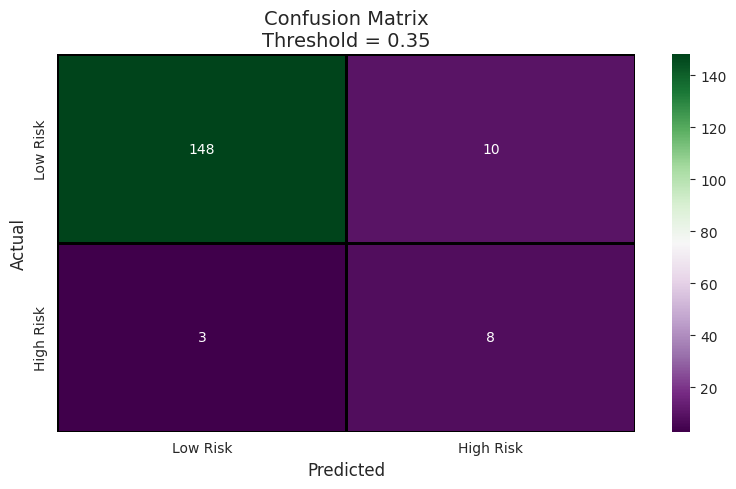

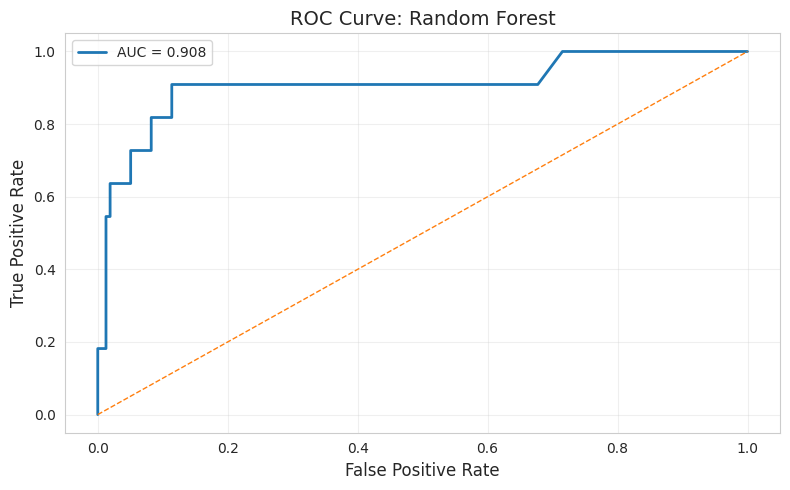

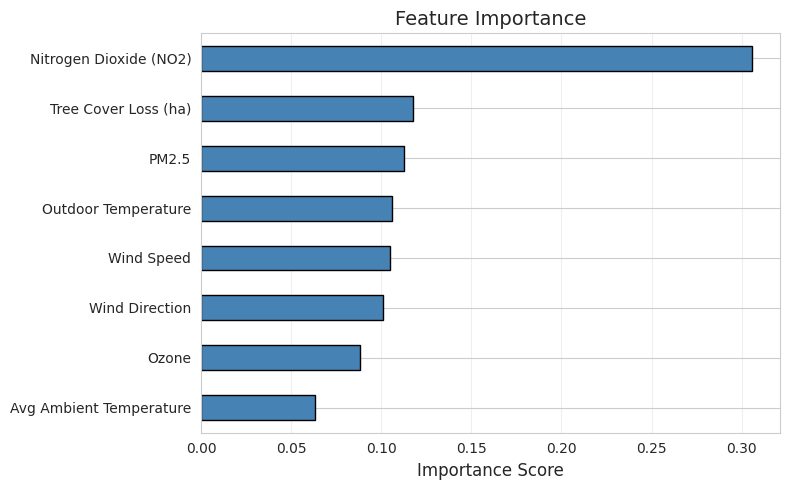


Feature Importance:
Nitrogen Dioxide (NO2)     0.3059
Tree Cover Loss (ha)       0.1178
PM2.5                      0.1127
Outdoor Temperature        0.1062
Wind Speed                 0.1050
Wind Direction             0.1011
Ozone                      0.0880
Avg Ambient Temperature    0.0634
dtype: float64


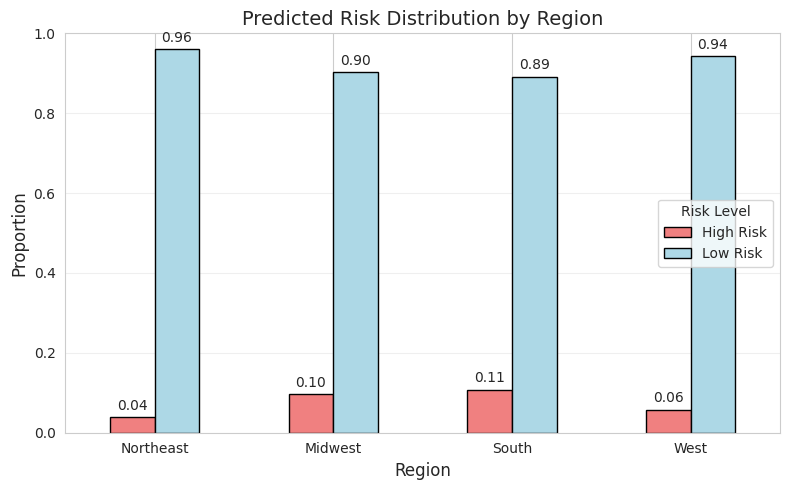

In [ ]:

feature_name_map = {
    "aqi_nitrogen_dioxide_no2": "Nitrogen Dioxide (NO2)",
    "veg_treecover_loss_ha": "Tree Cover Loss (ha)",
    "aqi_pm2_5_local_conditions": "PM2.5",
    "aqi_outdoor_temperature": "Outdoor Temperature",
    "aqi_wind_speed_resultant": "Wind Speed",
    "aqi_wind_direction_resultant": "Wind Direction",
    "aqi_ozone": "Ozone",
    "aqi_average_ambient_temperature": "Avg Ambient Temperature"
}


threshold_75 = df[target_col].quantile(0.75)
df["risk_level"] = (df[target_col] >= threshold_75).astype(int)

model_df = df[[target_col] + feature_cols + ["risk_level", "Region"]].dropna().copy()

X = model_df[feature_cols]
y = model_df["risk_level"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)


rf_model.fit(X_train, y_train)


val_prob = rf_model.predict_proba(X_val)[:, 1]

best_threshold = 0.5
best_score = -1

for t in np.arange(0.05, 0.96, 0.01):
    pred = (val_prob >= t).astype(int)
    score = f1_score(y_val, pred)
    if score > best_score:
        best_score = score
        best_threshold = t

print(f"Best Threshold: {best_threshold:.2f}")


y_prob = rf_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

print("\n=== 75th Percentile Results ===")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))


cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="PRGn",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"],
    linewidths=1,
    linecolor="black"
)
plt.title(f"Confusion Matrix\nThreshold = {best_threshold:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.title("ROC Curve: Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


rf_fitted = rf_model.named_steps["model"]

importance = pd.Series(
    rf_fitted.feature_importances_,
    index=[feature_name_map[col] for col in feature_cols]
)

plt.figure()
importance.sort_values().plot(
    kind="barh",
    edgecolor="black",
    color="steelblue"
)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(importance.sort_values(ascending=False).round(4))


model_df["predicted_risk"] = (rf_model.predict_proba(X)[:, 1] >= best_threshold).astype(int)

region_high = model_df.groupby("Region")["predicted_risk"].mean()
region_low = 1 - region_high


region_order = ["Northeast", "Midwest", "South", "West"]
region_high = region_high.loc[region_order]
region_low = region_low.loc[region_order]

region_compare = pd.DataFrame({
    "High Risk": region_high,
    "Low Risk": region_low
})


ax = region_compare.plot(
    kind="bar",
    color=["lightcoral", "lightblue"],
    edgecolor="black"
)


for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Predicted Risk Distribution by Region")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Risk Level")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

50-50 for checking


=== 50/50 SPLIT RESULTS ===
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       135
           1       0.60      0.35      0.44        34

    accuracy                           0.82       169
   macro avg       0.73      0.65      0.67       169
weighted avg       0.80      0.82      0.80       169

AUC: 0.8026143790849674


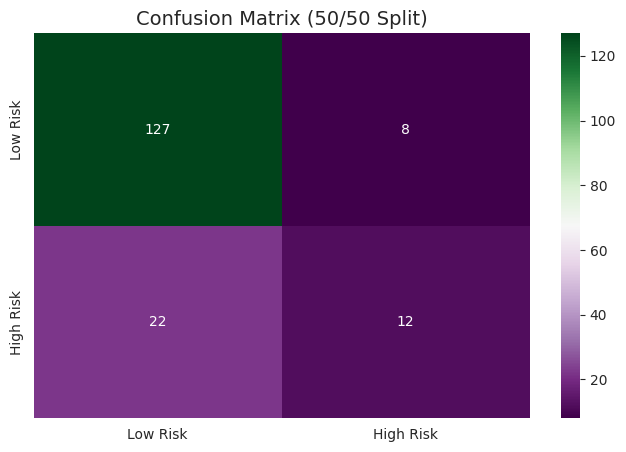

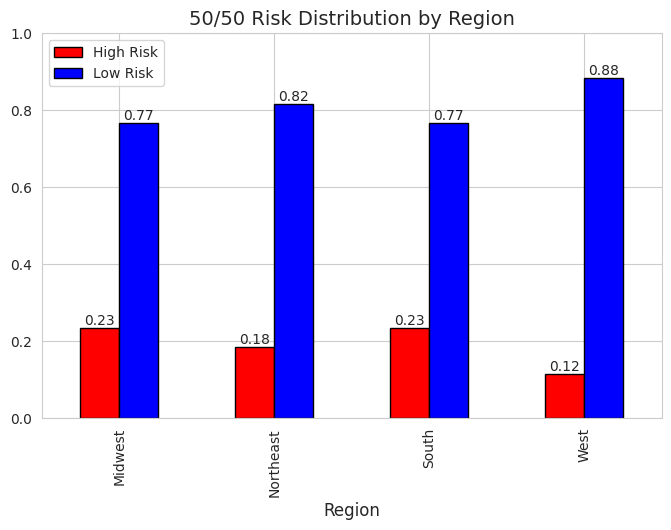

In [ ]:

threshold_50 = df[target_col].quantile(0.50)
df["risk_level_50"] = (df[target_col] >= threshold_50).astype(int)

if county_col is not None:
    df["state_abbr"] = df[county_col].astype(str).str.extract(r',\s*([A-Z]{2})$')
elif state_abbr_col is not None:
    df["state_abbr"] = df[state_abbr_col].astype(str).str.upper().str.strip()
else:
    print("Warning: Cannot determine state abbreviation for region mapping. 'state_abbr' column not created.")

region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast', 'RI': 'Northeast',
    'VT': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest',
    'MI': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest',
    'ND': 'Midwest', 'OH': 'Midwest', 'SD': 'Midwest', 'WI': 'Midwest',
    'AL': 'South', 'AR': 'South', 'DE': 'South', 'FL': 'South', 'GA': 'South',
    'KY': 'South', 'LA': 'South', 'MD': 'South', 'MS': 'South', 'NC': 'South',
    'OK': 'South', 'SC': 'South', 'TN': 'South', 'TX': 'South', 'VA': 'South',
    'WV': 'South', 'DC': 'South',
    'AK': 'West', 'AZ': 'West', 'CA': 'West', 'CO': 'West', 'HI': 'West',
    'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West', 'OR': 'West',
    'UT': 'West', 'WA': 'West', 'WY': 'West',
}

df["Region"] = df["state_abbr"].map(region_map)

model_df_50 = df[[target_col] + feature_cols + ["risk_level_50", "Region"]].dropna().copy()

X_50 = model_df_50[feature_cols]
y_50 = model_df_50["risk_level_50"]


X_train, X_temp, y_train, y_temp = train_test_split(
    X_50, y_50, test_size=0.30, random_state=42, stratify=y_50
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)


rf_model.fit(X_train, y_train)


val_prob = rf_model.predict_proba(X_val)[:, 1]

best_threshold = 0.5
best_score = -1

for t in np.arange(0.05, 0.96, 0.01):
    pred = (val_prob >= t).astype(int)
    score = f1_score(y_val, pred)
    if score > best_score:
        best_score = score
        best_threshold = t

y_prob = rf_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

print("=== 50/50 SPLIT RESULTS ===")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))


cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="PRGn",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)
plt.title("Confusion Matrix (50/50 Split)")
plt.show()


model_df_50["predicted"] = (rf_model.predict_proba(X_50)[:, 1] >= best_threshold).astype(int)

region_high = model_df_50.groupby("Region")["predicted"].mean()
region_low = 1 - region_high

region_compare = pd.DataFrame({
    "High Risk": region_high,
    "Low Risk": region_low
})

ax = region_compare.plot(
    kind="bar",
    color=["red", "blue"],
    edgecolor="black"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.ylim(0, 1)
plt.title("50/50 Risk Distribution by Region")
plt.show()